In [ ]:
from google.colab import files
uploaded = files.upload()

In [23]:
import zipfile

with zipfile.ZipFile("bank-data.zip", 'r') as zip_ref:
    zip_ref.extractall("bank_data")

print("Extraction done!")

Extraction done!


In [24]:
import os
for root, dirs, files_ in os.walk("bank_data"):
    for f in files_:
        print(os.path.join(root, f))


bank_data/bank-data/bank-full.csv
bank_data/bank-data/.DS_Store
bank_data/__MACOSX/._bank-data
bank_data/__MACOSX/bank-data/._bank-full.csv
bank_data/__MACOSX/bank-data/._.DS_Store


In [25]:
import pandas as pd

df = pd.read_csv("bank_data/bank-data/bank-full.csv", sep=';')
print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [26]:
# Basic info
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution (y):\n", df['y'].value_counts())
print("\nTarget distribution (%):\n", df['y'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Missing values:
 age          0
job          0
marital      0
education    0
default      0
balanc

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


df['y'] = df['y'].map({'no': 0, 'yes': 1})


categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nEncoded shape:", df_encoded.shape)

# Features এবং target আলাদা করা
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Train-test split (stratify দিয়ে class balance বজায় রাখা)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Encoded shape: (45211, 43)

Train shape: (36168, 42)
Test shape: (9043, 42)


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)

# Evaluation
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.9006966714585868
Precision: 0.644927536231884
Recall: 0.33648393194706994
F1-Score: 0.4422360248447205

Confusion Matrix:
[[7789  196]
 [ 702  356]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.64      0.34      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.69      9043
weighted avg       0.89      0.90      0.89      9043



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

print("Model training completed!")

Model training completed!


In [30]:
print("Actual values:")
print(y_test.values[:20])

print("\nPredicted values:")
print(y_pred[:20])

Actual values:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]

Predicted values:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.901249585314608
Precision: 0.643979057591623
Recall   : 0.3487712665406427
F1-Score : 0.45248313917841815


Confusion Matrix:
[[7781  204]
 [ 689  369]]


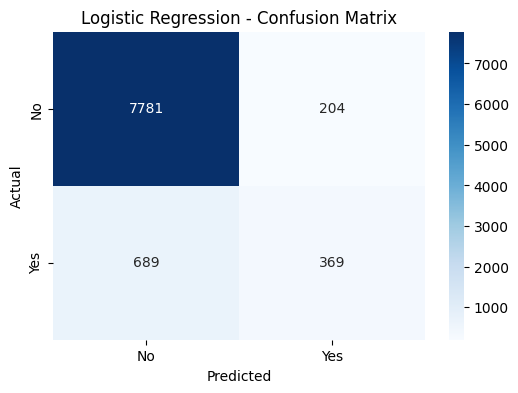

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['No', 'Yes']
))

              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [34]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['No', 'Yes']
))

              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [35]:
import joblib

joblib.dump(model, "logistic_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!
